In [ ]:
clawhub install tushare-data

In [1]:
pip install tushare -i https://pypi.tuna.tsinghua.edu.cn/simple

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     |████████████████████████████████| 142 kB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 90 kB 4.8 MB/s eta 0:00:011
     |████████████████████████████████| 82 kB 3.3 MB/s eta 0:00:011
     |████████████████████████████████| 10.8 MB 1.1 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 4.0 MB/s eta 0:00:011
     |████████████████████████████████| 8.6 MB 3.7 MB/s eta 0:00:01
     |████████████████████████████████| 109 kB 4.0 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 1.2 MB/s eta 0:00:01
     |████████████████████████████████| 349 kB 4.3 MB/s eta 0:00:01
     |████████████████████████████████| 510 kB 1.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use up

In [2]:
# 配置token
import tushare as ts
ts.set_token('aaf703beee8465430570fc26ccd9d0266946f1e7a72fae423a7887e6')

/Users/stella/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 3.4 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 3.7 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 3.3 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 3.3 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 2.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 设置 token
# ts.set_token('your_tushare_token_here')  # 替换成你的 token
pro = ts.pro_api()

ts_code = '600900.SH'
start_date = '20250630'
end_date = '20260628'

# 1. 获取日线行情（不复权）
daily = pro.daily(
    ts_code=ts_code,
    start_date=start_date,
    end_date=end_date
)

# 2. 获取复权因子
adj = pro.adj_factor(
    ts_code=ts_code,
    start_date=start_date,
    end_date=end_date
)

# 3. 合并数据
df = pd.merge(daily, adj[['trade_date', 'adj_factor']], on='trade_date', how='left')
df = df.sort_values('trade_date')
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df['close'] = df['close'].astype(float)
df['adj_factor'] = df['adj_factor'].astype(float)

# 4. 计算前复权、后复权收盘价
latest_factor = df['adj_factor'].iloc[-1]      # 最新一日的复权因子
first_factor = df['adj_factor'].iloc[0]        # 区间首日复权因子

df['close_hfq'] = df['close'] * df['adj_factor']                    # 后复权
df['close_qfq'] = df['close'] * df['adj_factor'] / latest_factor    # 前复权
df['close_raw'] = df['close']                                        # 不复权

# 5. 保存 CSV
df.to_csv('cypower_daily_till_20260628.csv', index=False, encoding='utf-8-sig')
print("数据已保存为 cypower_daily_till_20260628.csv")

# 6. 画图
plt.figure(figsize=(14, 7))
plt.plot(df['trade_date'], df['close_raw'], label='不复权', color='gray', linestyle='--', alpha=0.8)
plt.plot(df['trade_date'], df['close_qfq'], label='前复权', color='steelblue', linewidth=2)
plt.plot(df['trade_date'], df['close_hfq'], label='后复权', color='coral', linewidth=2)

plt.title('长江电力（600900.SH）每日收盘价走势（分红复权对比）', fontsize=14)
plt.xlabel('日期', fontsize=12)
plt.ylabel('收盘价（元）', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Exception: 抱歉，您访问接口(adj_factor)频率超限(1次/小时)，具体频次详情：https://tushare.pro/document/1?doc_id=108。

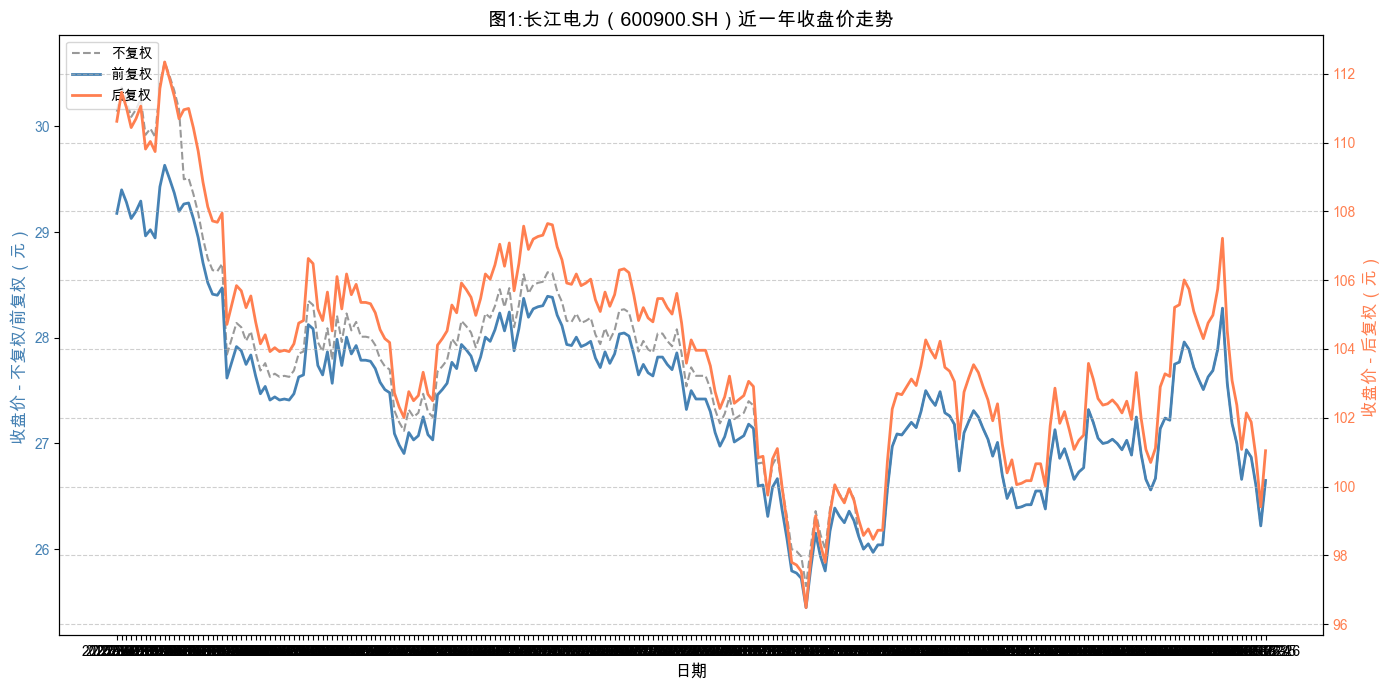

In [6]:
# 直接用本地数据画图
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 读取本地数据
df = pd.read_csv('cypower_daily_till_20260628.csv')

# 修复中文显示
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS
matplotlib.rcParams['axes.unicode_minus'] = False              # 负号正常显示

# 画图：使用双Y轴
fig, ax1 = plt.subplots(figsize=(14, 7))

# 左Y轴：不复权 + 前复权
ax1.plot(df['trade_date'], df['close_raw'], label='不复权', color='gray', linestyle='--', alpha=0.8)
ax1.plot(df['trade_date'], df['close_qfq'], label='前复权', color='steelblue', linewidth=2)
ax1.set_xlabel('日期', fontsize=12)
ax1.set_ylabel('收盘价 - 不复权/前复权（元）', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# 右Y轴：后复权
ax2 = ax1.twinx()
ax2.plot(df['trade_date'], df['close_hfq'], label='后复权', color='coral', linewidth=2)
ax2.set_ylabel('收盘价 - 后复权（元）', fontsize=12, color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('图1:长江电力（600900.SH）近一年收盘价走势', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 模块 1：数据准备与收益率计算

数据加载完成：241 个交易日
日期范围：2025-06-30 ~ 2026-06-26


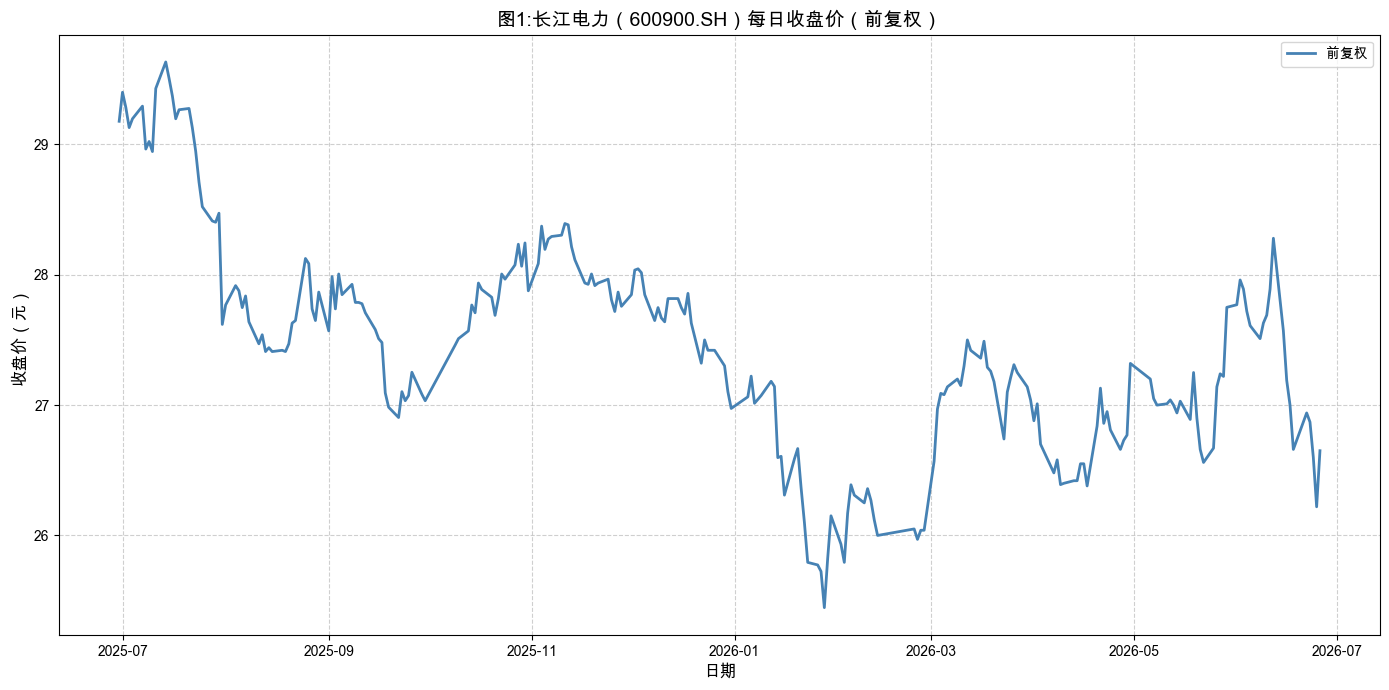

In [1]:
# 模块1: 数据准备与收益率计算
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# macOS 中文字体配置
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# 1.1 数据加载
df = pd.read_csv('cypower_daily_till_20260628.csv')
df['trade_date'] = pd.to_datetime(df['trade_date'])
df['close_qfq'] = df['close_qfq'].astype(float)
df = df.sort_values('trade_date').reset_index(drop=True)

# 1.2 收益率计算
df['daily_return'] = df['close_qfq'].pct_change()
df['cum_return'] = (1 + df['daily_return']).cumprod() - 1

print(f"数据加载完成：{len(df)} 个交易日")
print(f"日期范围：{df['trade_date'].iloc[0].strftime('%Y-%m-%d')} ~ {df['trade_date'].iloc[-1].strftime('%Y-%m-%d')}")
df[['trade_date', 'close_qfq', 'daily_return', 'cum_return']].head(10)

# 6. 画图
plt.figure(figsize=(14, 7))
plt.plot(df['trade_date'], df['close_qfq'], label='前复权', color='steelblue', linewidth=2)
plt.title('图1:长江电力（600900.SH）每日收盘价（前复权）', fontsize=14)
plt.xlabel('日期', fontsize=12)
plt.ylabel('收盘价（元）', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 模块 2：描述性统计汇总表

In [2]:
# 模块2: 描述性统计汇总表
price = df['close_qfq']
ret = df['daily_return'].dropna()
N = len(price)

# 价格统计
price_stats = pd.DataFrame({
    '指标': ['样本数 N', '均值', '中位数', '标准差', '最小值', '最大值', '变异系数 CV'],
    '价格(close_qfq)': [
        N,
        f'{price.mean():.4f}',
        f'{price.median():.4f}',
        f'{price.std():.4f}',
        f'{price.min():.4f}',
        f'{price.max():.4f}',
        f'{price.std() / price.mean():.4f}'
    ]
})

# 收益率统计
ret_stats = pd.DataFrame({
    '指标': ['样本数 N', '均值', '中位数', '标准差', '最小值', '最大值', '偏度', '峰度'],
    '日收益率': [
        len(ret),
        f'{ret.mean():.6f}',
        f'{ret.median():.6f}',
        f'{ret.std():.6f}',
        f'{ret.min():.6f}',
        f'{ret.max():.6f}',
        f'{ret.skew():.4f}',
        f'{ret.kurt():.4f}'
    ]
})

# 年化指标
ann_return = (price.iloc[-1] / price.iloc[0]) ** (252 / N) - 1
ann_vol = ret.std() * np.sqrt(252)

ann_stats = pd.DataFrame({
    '指标': ['年化收益率', '年化波动率'],
    '值': [f'{ann_return:.4%}', f'{ann_vol:.4%}']
})

print('=== 价格统计 ===')
display(price_stats)
print('\n=== 收益率统计 ===')
display(ret_stats)
print('\n=== 年化指标 ===')
display(ann_stats)

=== 价格统计 ===


,指标,价格(close_qfq)
0,样本数 N,241
1,均值,27.4378
2,中位数,27.4404
3,标准差,0.8147
4,最小值,25.4464
5,最大值,29.6323
6,变异系数 CV,0.0297



=== 收益率统计 ===


,指标,日收益率
0,样本数 N,240
1,均值,-0.000349
2,中位数,-0.000752
3,标准差,0.007528
4,最小值,-0.029965
5,最大值,0.020545
6,偏度,0.0637
7,峰度,1.4057



=== 年化指标 ===


,指标,值
0,年化收益率,-9.0388%
1,年化波动率,11.9510%


## 模块 3：日收益率分布图

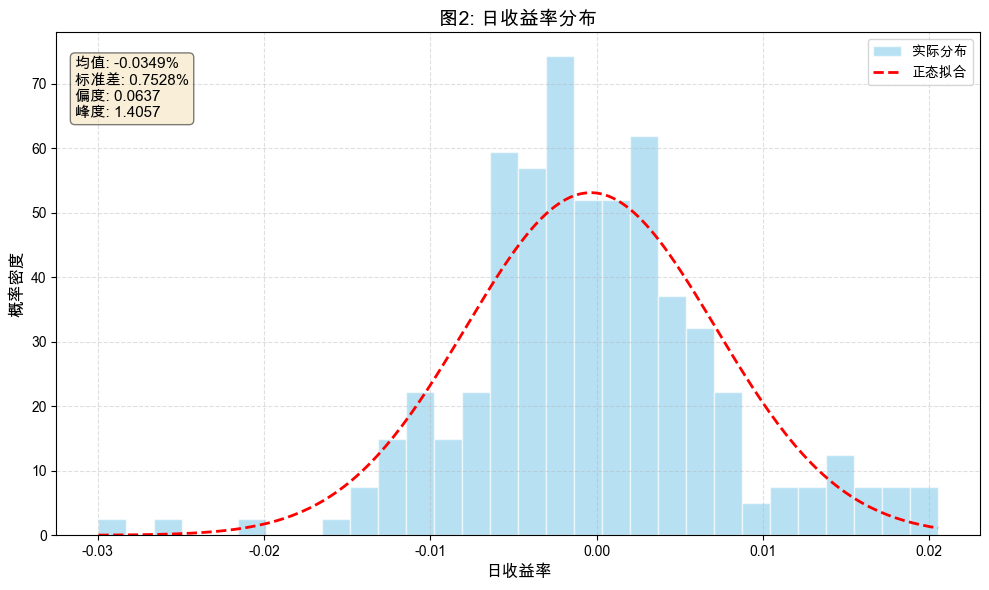

In [3]:
# 模块3: 日收益率分布图
ret = df['daily_return'].dropna()
mu, sigma = stats.norm.fit(ret)
x = np.linspace(ret.min(), ret.max(), 200)
pdf = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(ret, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='white', label='实际分布')
ax.plot(x, pdf, 'r--', linewidth=2, label='正态拟合')

# 标注统计量
textstr = (f'均值: {ret.mean():.4%}\n'
           f'标准差: {ret.std():.4%}\n'
           f'偏度: {ret.skew():.4f}\n'
           f'峰度: {ret.kurt():.4f}')
ax.text(0.02, 0.95, textstr, transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_title('图2: 日收益率分布', fontsize=14)
ax.set_xlabel('日收益率', fontsize=12)
ax.set_ylabel('概率密度', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 模块 4：最大回撤分析（含 VaR / CVaR）

最大回撤: -14.1262%
回撤区间: 2025-07-14 ~ 2026-01-28
VaR (95%): -1.1492%
CVaR (95%): -1.6341%


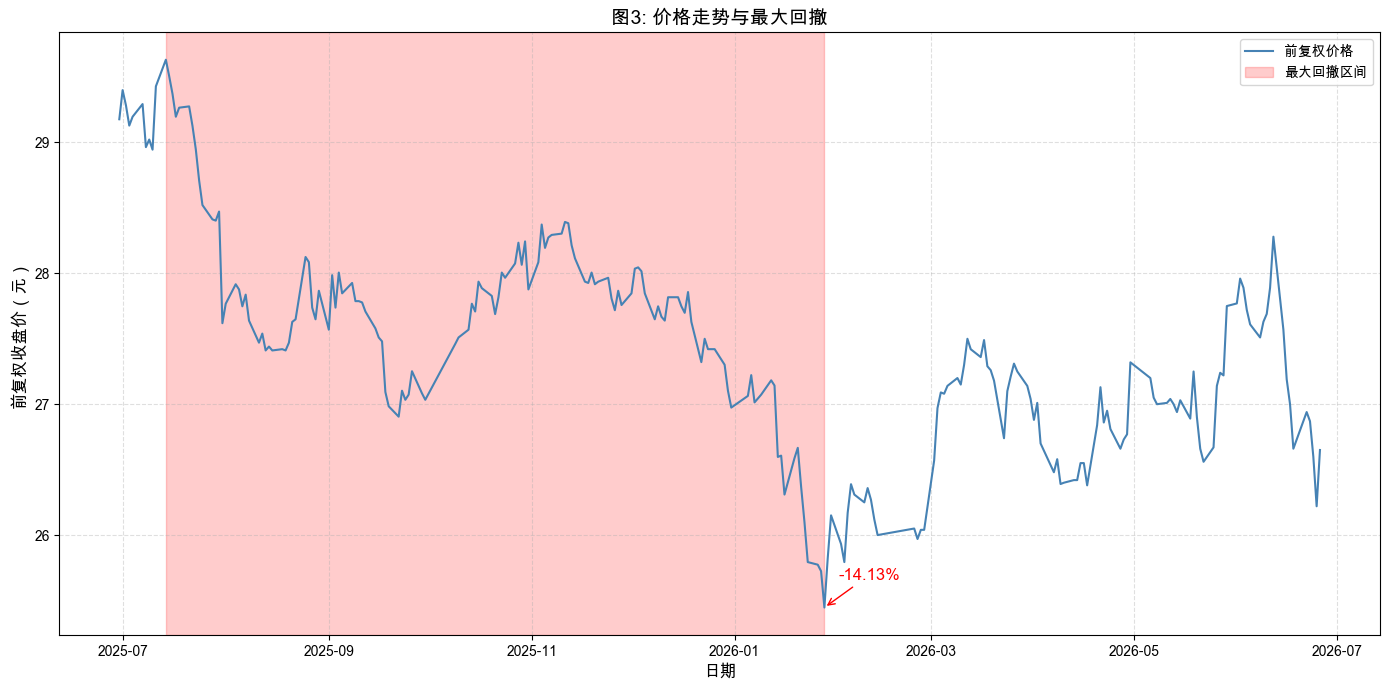

In [4]:
# 模块4: 最大回撤分析
price = df['close_qfq']
cum_max = price.cummax()
drawdown = (price - cum_max) / cum_max
max_dd = drawdown.min()

# 定位回撤区间
dd_end_idx = drawdown.idxmin()
dd_start_idx = price[:dd_end_idx + 1].idxmax()
dd_start_date = df.loc[dd_start_idx, 'trade_date']
dd_end_date = df.loc[dd_end_idx, 'trade_date']

# VaR 与 CVaR (95%)
ret = df['daily_return'].dropna()
var_95 = np.percentile(ret, 5)
cvar_95 = ret[ret <= var_95].mean()

print(f'最大回撤: {max_dd:.4%}')
print(f'回撤区间: {dd_start_date.strftime("%Y-%m-%d")} ~ {dd_end_date.strftime("%Y-%m-%d")}')
print(f'VaR (95%): {var_95:.4%}')
print(f'CVaR (95%): {cvar_95:.4%}')

# 绘图
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df['trade_date'], price, color='steelblue', linewidth=1.5, label='前复权价格')
ax.axvspan(dd_start_date, dd_end_date, alpha=0.2, color='red', label='最大回撤区间')
ax.annotate(f'{max_dd:.2%}', xy=(dd_end_date, price.iloc[dd_end_idx]),
            fontsize=12, color='red', fontweight='bold',
            xytext=(10, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('图3: 价格走势与最大回撤', fontsize=14)
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('前复权收盘价（元）', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 模块 5：ADF 平稳性检验

In [5]:
# 模块5: ADF 平稳性检验
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        '序列': name,
        'ADF 统计量': f'{result[0]:.4f}',
        'p 值': f'{result[1]:.4f}',
        '滞后阶数': result[2],
        '1% 临界值': f'{result[4]["1%"]:.4f}',
        '5% 临界值': f'{result[4]["5%"]:.4f}',
        '10% 临界值': f'{result[4]["10%"]:.4f}',
        '结论': '平稳' if result[1] < 0.05 else '不平稳'
    }

adf_results = pd.DataFrame([
    adf_test(df['close_qfq'], '前复权收盘价'),
    adf_test(df['daily_return'], '日收益率')
])

print('=== ADF 平稳性检验 ===')
display(adf_results)

=== ADF 平稳性检验 ===


,序列,ADF 统计量,p 值,滞后阶数,1% 临界值,5% 临界值,10% 临界值,结论
0,前复权收盘价,-2.4422,0.1302,0,-3.4579,-2.8737,-2.5732,不平稳
1,日收益率,-15.7748,0.0000,0,-3.4580,-2.8737,-2.5733,平稳


## 模块 6：小结

In [9]:
# 模块6: 小结 - 综合指标汇总表
price = df['close_qfq']
ret = df['daily_return'].dropna()
N = len(price)

summary = pd.DataFrame({
    '类别': ['价格分布', '', '', '', '', '',
             '收益率', '', '', '', '',
             '风险', '', '', ''],
    '指标': ['均值', '中位数', '标准差', '变异系数 CV', '最小值', '最大值',
             '年化收益率', '日均收益率', '日收益率标准差', '偏度', '峰度',
             '年化波动率', '最大回撤', 'VaR (95%)', 'CVaR (95%)'],
    '值': [
        f'{price.mean():.4f}',
        f'{price.median():.4f}',
        f'{price.std():.4f}',
        f'{price.std() / price.mean():.4f}',
        f'{price.min():.4f}',
        f'{price.max():.4f}',
        f'{((price.iloc[-1] / price.iloc[0]) ** (252 / N) - 1):.4%}',
        f'{ret.mean():.4%}',
        f'{ret.std():.4%}',
        f'{ret.skew():.4f}',
        f'{ret.kurt():.4f}',
        f'{ret.std() * np.sqrt(252):.4%}',
        f'{max_dd:.4%}',
        f'{var_95:.4%}',
        f'{cvar_95:.4%}'
    ]
})

print('=== 综合指标汇总 ===')
display(summary)

# ADF 检验结果
print('=== ADF 平稳性检验结果 ===')
display(adf_results)

=== 综合指标汇总 ===


,类别,指标,值
0,价格分布,均值,27.4378
1,,中位数,27.4404
2,,标准差,0.8147
3,,变异系数 CV,0.0297
4,,最小值,25.4464
5,,最大值,29.6323
6,收益率,年化收益率,-9.0388%
7,,日均收益率,-0.0349%
8,,日收益率标准差,0.7528%
9,,偏度,0.0637


=== ADF 平稳性检验结果 ===


,序列,ADF 统计量,p 值,滞后阶数,1% 临界值,5% 临界值,10% 临界值,结论
0,前复权收盘价,-2.4422,0.1302,0,-3.4579,-2.8737,-2.5732,不平稳
1,日收益率,-15.7748,0.0000,0,-3.4580,-2.8737,-2.5733,平稳
